# Open-channel hydraulics

Uniform flow, critical flow, specific energy, hydraulic jumps and gradually varied flow
profiles in prismatic channels.

In [1]:
try:
    import fluidmech
except ImportError:  # e.g. on Google Colab
    %pip install -q git+https://github.com/ktwyw/fluidmech.git
    import fluidmech
print("fluidmech", fluidmech.__version__)

fluidmech 0.3.0


In [2]:
import matplotlib.pyplot as plt
from fluidmech.open_channel import (TrapezoidalChannel, RectangularChannel, MANNING_N, gvf_profile,
                                    classify_profile, hydraulic_jump_depth, hydraulic_jump_energy_loss)

## 1. Normal depth — Manning's equation

$$Q = \frac{1}{n} A R^{2/3} S_0^{1/2}$$

In [3]:
canal = TrapezoidalChannel(bottom_width=4.0, side_slope=1.5)
n, S0, Q = MANNING_N["finished_concrete"], 0.0008, 25.0
yn = canal.normal_depth(Q, n, S0)
yc = canal.critical_depth(Q)
print(f"normal depth {yn:.3f} m, critical depth {yc:.3f} m, Fr = {canal.froude(yn, Q):.2f} "
      f"-> {'mild' if yn > yc else 'steep'} slope")

normal depth 1.603 m, critical depth 1.332 m, Fr = 0.72 -> mild slope


## 2. Specific energy

$$E = y + \frac{Q^2}{2 g A^2}$$

Every $E > E_{min}$ can occur at two *alternate depths*; the minimum occurs at critical depth.

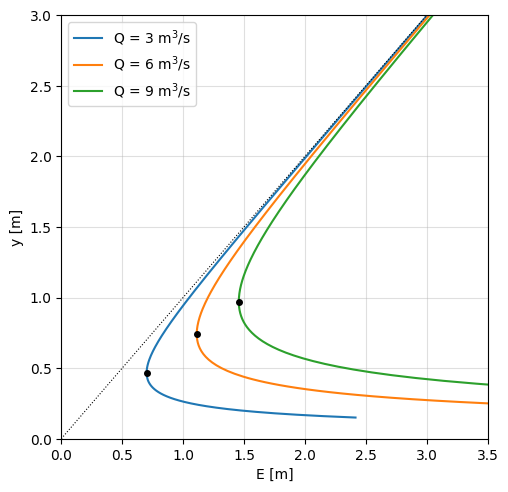

In [4]:
ch = RectangularChannel(3.0)
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ys = [0.15 + 0.01 * i for i in range(300)]
for q in (3, 6, 9):
    ax.plot([ch.specific_energy(y, q) for y in ys], ys, label=f"Q = {q} m$^3$/s")
    yc_q = ch.critical_depth(q)
    ax.plot(ch.specific_energy(yc_q, q), yc_q, "ko", ms=4)
ax.plot([0, 3.5], [0, 3.5], "k:", lw=0.8)
ax.set_xlim(0, 3.5); ax.set_ylim(0, 3); ax.set_xlabel("E [m]"); ax.set_ylabel("y [m]")
ax.legend(); ax.grid(alpha=0.4); plt.show()

## 3. Backwater curve behind a weir

A weir raises the depth to 2.8 m. On a mild slope the water surface follows an **M1** profile,
computed here with the direct step method:

$$\Delta x = \frac{E_2 - E_1}{S_0 - \bar S_f}$$

profile type: M1


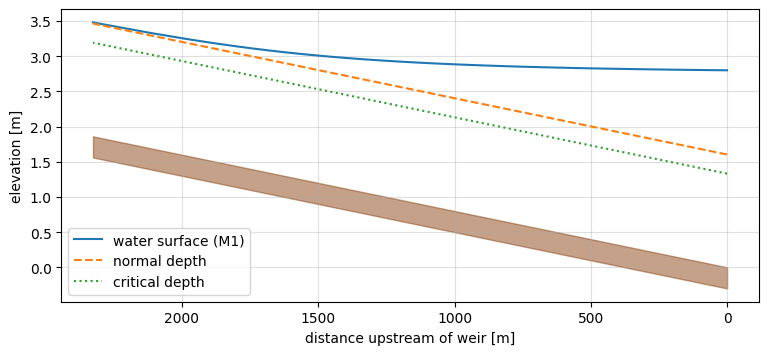

The weir affects the river 2.33 km upstream.


In [5]:
print("profile type:", classify_profile(canal, Q, n, S0, 2.8))
prof = gvf_profile(canal, Q, n, S0, start_depth=2.8, end_depth=1.01 * yn, steps=60)
x = [-p[0] for p in prof]
bed = [S0 * xi for xi in x]
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(x, [b + p[1] for b, p in zip(bed, prof)], label="water surface (M1)")
ax.plot(x, [b + yn for b in bed], "--", label="normal depth")
ax.plot(x, [b + yc for b in bed], ":", label="critical depth")
ax.fill_between(x, [b - 0.3 for b in bed], bed, color="saddlebrown", alpha=0.5)
ax.invert_xaxis(); ax.set_xlabel("distance upstream of weir [m]"); ax.set_ylabel("elevation [m]")
ax.legend(); ax.grid(alpha=0.4); plt.show()
print(f"The weir affects the river {x[-1]/1000:.2f} km upstream.")

## 4. Hydraulic jump

$$\frac{y_2}{y_1} = \tfrac12\left(\sqrt{1 + 8 Fr_1^2} - 1\right), \qquad
\Delta E = \frac{(y_2-y_1)^3}{4 y_1 y_2}$$

In [6]:
y1 = 0.3
for fr1 in (2, 4, 6, 9):
    y2 = hydraulic_jump_depth(y1, fr1)
    print(f"Fr1 = {fr1}: y2 = {y2:.2f} m, head lost {hydraulic_jump_energy_loss(y1, y2):.2f} m")

Fr1 = 2: y2 = 0.71 m, head lost 0.08 m
Fr1 = 4: y2 = 1.55 m, head lost 1.06 m
Fr1 = 6: y2 = 2.40 m, head lost 3.22 m
Fr1 = 9: y2 = 3.67 m, head lost 8.70 m
